In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import seaborn as sn
import pandas as pd
import numpy as np
import os
from timeit import default_timer as timer
from tqdm.auto import tqdm
from typing import Dict, List
from sklearn.metrics import confusion_matrix, classification_report
import math

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Używam urządzenia: {device}")

NUM_WORKERS = os.cpu_count()
BATCH_SIZE = 128
NUM_EPOCHS = 50

learning_rate = 0.001
weight_decay = 1e-2
DROP_RATE = 0.1  # Dodajemy Dropout 10%
grad_clip = None

Używam urządzenia: cuda


In [ ]:
model_name = "DenseNet121"
date = "260119"
run_id = f"{date}_{model_name}_epoch{NUM_EPOCHS}_dodany_dropout"
base_directory = "/content/drive/MyDrive/TAI/sem2/DL/densenet_40"
project_directory = os.path.join(base_directory, run_id)
os.makedirs(project_directory, exist_ok=True)

# Przygotowanie danych

In [ ]:
mean, std = [0.4914, 0.4822, 0.4465], [0.247, 0.2435, 0.2616]

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print("Dane załadowane.")

Dane załadowane.


# Definicja modelu

Zmiany w DenseNet dla CIFAR-10:
- zmiana pierwszej warstwy z Conv 7x7 (stride 2) na Conv 3x3 (stride 1), aby nie tracić detali na starcie

- wycięcie początkowego zmniejszania obrazu (MaxPool)- do pierwszego bloku wchodzi pełne 32x32 (w oryginale wchodziłoby zredukowane obrazy)

- wprowadzenie losowego wyłączania neuronów (dropout) - dla cifar-10 pamaga przed przeuczeniem

- używanie AdaptiveAvgPool, który zawsze zwraca wynik 1x1, niezależnie od wielkości mapy cech

- zmiana ostatniej warstwy Linear z 1000 klas na 10

In [ ]:
class Bottleneck(nn.Module):
    def __init__(self, in_planes, growth_rate, drop_rate=0.0):
        super(Bottleneck, self).__init__()
        self.bn1 = nn.BatchNorm2d(in_planes)
        self.conv1 = nn.Conv2d(in_planes, 4*growth_rate, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(4*growth_rate)
        self.conv2 = nn.Conv2d(4*growth_rate, growth_rate, kernel_size=3, padding=1, bias=False)
        self.drop_rate = drop_rate

    def forward(self, x):
        out = self.conv1(F.relu(self.bn1(x)))
        out = self.conv2(F.relu(self.bn2(out)))
        if self.drop_rate > 0:
            out = F.dropout(out, p=self.drop_rate, training=self.training)
        out = torch.cat([out, x], 1)
        return out

class Transition(nn.Module):
    def __init__(self, in_planes, out_planes):
        super(Transition, self).__init__()
        self.bn = nn.BatchNorm2d(in_planes)
        self.conv = nn.Conv2d(in_planes, out_planes, kernel_size=1, bias=False)

    def forward(self, x):
        out = self.conv(F.relu(self.bn(x)))
        out = F.avg_pool2d(out, 2)
        return out

class DenseNet(nn.Module):
    def __init__(self, block, nblocks, growth_rate=32, reduction=0.5, num_classes=10, drop_rate=0.0):
        super(DenseNet, self).__init__()
        self.growth_rate = growth_rate
        self.drop_rate = drop_rate

        num_planes = 2 * growth_rate
        self.conv1 = nn.Conv2d(3, num_planes, kernel_size=3, padding=1, bias=False)

        self.layers = nn.ModuleList()
        for i, num_layers in enumerate(nblocks):
            block_layer = self._make_dense_layers(block, num_planes, num_layers)
            self.layers.append(block_layer)
            num_planes += num_layers * growth_rate

            if i != len(nblocks) - 1:
                out_planes = int(math.floor(num_planes * reduction))
                trans_layer = Transition(num_planes, out_planes)
                self.layers.append(trans_layer)
                num_planes = out_planes

        self.bn = nn.BatchNorm2d(num_planes)
        self.linear = nn.Linear(num_planes, num_classes)

    def _make_dense_layers(self, block, in_planes, nblock):
        layers = []
        for i in range(nblock):
            layers.append(block(in_planes, self.growth_rate, drop_rate=self.drop_rate))
            in_planes += self.growth_rate
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.conv1(x)
        for layer in self.layers:
            out = layer(out)

        out = F.relu(self.bn(out))
        out = F.adaptive_avg_pool2d(out, (1, 1))
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out

def densenet121_cifar(drop_rate=0.0):
    return DenseNet(Bottleneck, [6, 12, 24, 16], growth_rate=32, drop_rate=drop_rate)

# Funkcje pomocnicze do treningu

In [ ]:
def train_step(model:nn.Module,
               dataloader:torch.utils.data.DataLoader,
               loss_fn:nn.Module,
               optimizer:torch.optim.Optimizer,
               scheduler:torch.optim.lr_scheduler,
               grad_clip:float):
  model.train()
  train_loss, train_acc = 0, 0
  for batch, (X,y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)
    y_pred = model(X)
    loss = loss_fn(y_pred, y)
    train_loss += loss.item()
    optimizer.zero_grad()
    loss.backward()
    if grad_clip:
      nn.utils.clip_grad_value_(model.parameters(), grad_clip)
    optimizer.step()
    y_pred_class = torch.argmax(y_pred, dim=1)
    train_acc += (y_pred_class == y).sum().item() / len(y)
  train_loss /= len(dataloader)
  train_acc /= len(dataloader)
  if scheduler is not None:
    scheduler.step() # ubez train_loss (niepotrzebny dla CosineAnnealing)
  return train_loss, train_acc

def test_step(model:nn.Module,
              dataloader:torch.utils.data.DataLoader,
              loss_fn:nn.Module):
  model.eval()
  test_loss, test_acc = 0, 0
  with torch.inference_mode():
    for batch, (X,y) in enumerate(dataloader):
      X, y = X.to(device), y.to(device)
      test_pred_logits = model(X)
      loss = loss_fn(test_pred_logits, y)
      test_loss += loss.item()
      test_pred_labels = torch.argmax(test_pred_logits, dim=1)
      test_acc += (test_pred_labels == y).sum().item() / len(y)
    test_loss /= len(dataloader)
    test_acc /= len(dataloader)
  return test_loss, test_acc

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          scheduler:torch.optim.lr_scheduler,
          grad_clip:float,
          loss_fn: torch.nn.Module,
          epochs: int):
    results = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model, train_dataloader, loss_fn, optimizer, scheduler, grad_clip)
        test_loss, test_acc = test_step(model, test_dataloader, loss_fn)
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)
        print(f"Epoch: {epoch+1} | train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f} | test_loss: {test_loss:.4f} | test_acc: {test_acc:.4f}")
    return results

def plot_loss_curves(results: Dict[str, List[float]], save_path: str = None, model_name: str = None, learning_rate: float = None, weight_decay: float = None, grad_clip: float = None):
    loss = results['train_loss']
    test_loss = results['test_loss']
    accuracy = results['train_acc']
    test_accuracy = results['test_acc']
    epochs = range(len(results['train_loss']))
    title_suffix = model_name
    if learning_rate is not None: title_suffix += f" | Learning rate: {learning_rate}"
    if weight_decay is not None: title_suffix += f" | Weight decay: {weight_decay}"
    if grad_clip is not None: title_suffix += f" | Grad clip: {grad_clip}"
    title_suffix += f" | Epochs: {len(results['train_loss'])}"
    title_suffix += f" | Batch size: {BATCH_SIZE}"
    plt.figure(figsize=(15, 7))
    plt.suptitle(title_suffix, fontsize=16)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, test_loss, label='test_loss')
    plt.title(f'Loss')
    plt.xlabel('Epochs')
    plt.grid()
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='train_accuracy')
    plt.plot(epochs, test_accuracy, label='test_accuracy')
    plt.title(f'Accuracy')
    plt.xlabel('Epochs')
    plt.grid()
    plt.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
        print(f"Plot saved to: {save_path}")
    plt.show()

# Trening

DenseNet-121

parametry:
- epoki=50
- batch size=128
- CrossEntropyLoss, label smoothing=0.1
- optymalizator: AdamW, lr=0.001, weight_decay=1e-2
- scheduler: cosineAnnealing, T_max=50(epoki)
- drop rate=10%
- grad_clip=NONE


Rozpoczynam trening modelu DenseNet121 (DenseNet-121) na 50 epok z AdamW i Dropout=0.1...


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.6348 | train_acc: 0.4705 | test_loss: 1.6111 | test_acc: 0.5514
Epoch: 2 | train_loss: 1.2885 | train_acc: 0.6433 | test_loss: 1.3311 | test_acc: 0.6424
Epoch: 3 | train_loss: 1.1498 | train_acc: 0.7116 | test_loss: 1.3235 | test_acc: 0.6686
Epoch: 4 | train_loss: 1.0503 | train_acc: 0.7548 | test_loss: 1.1246 | test_acc: 0.7432
Epoch: 5 | train_loss: 0.9751 | train_acc: 0.7928 | test_loss: 1.0618 | test_acc: 0.7640
Epoch: 6 | train_loss: 0.9271 | train_acc: 0.8134 | test_loss: 0.9916 | test_acc: 0.7973
Epoch: 7 | train_loss: 0.8854 | train_acc: 0.8317 | test_loss: 1.3239 | test_acc: 0.6954
Epoch: 8 | train_loss: 0.8536 | train_acc: 0.8456 | test_loss: 0.8491 | test_acc: 0.8560
Epoch: 9 | train_loss: 0.8257 | train_acc: 0.8604 | test_loss: 0.8898 | test_acc: 0.8385
Epoch: 10 | train_loss: 0.8064 | train_acc: 0.8669 | test_loss: 0.8266 | test_acc: 0.8651
Epoch: 11 | train_loss: 0.7799 | train_acc: 0.8784 | test_loss: 0.8499 | test_acc: 0.8581
Epoch: 12 | train_l

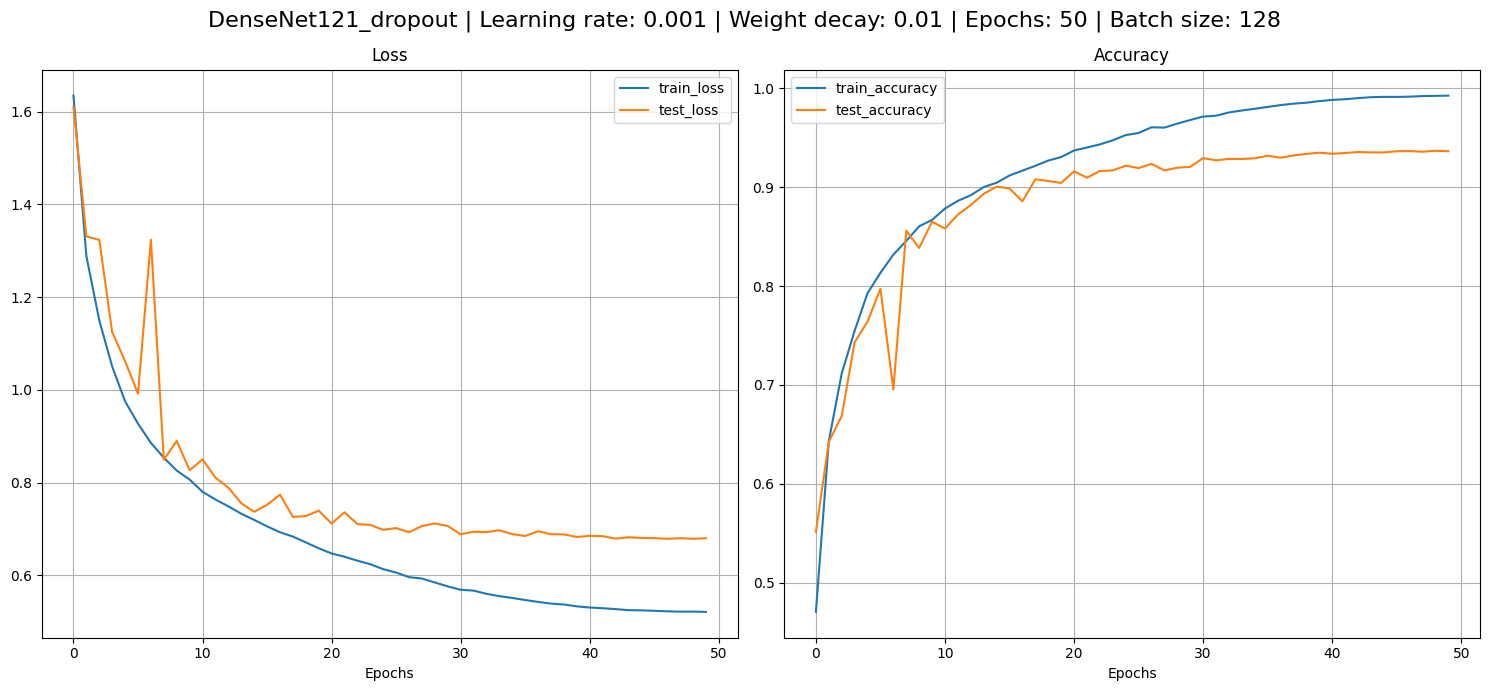

In [ ]:
model = densenet121_cifar(drop_rate=DROP_RATE).to(device)
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

print(f"Rozpoczynam trening modelu {model_name} (DenseNet-121) na 50 epok z AdamW i Dropout={DROP_RATE}...")
start_time = timer()
model_results = train(model, train_dataloader, test_dataloader, optimizer, scheduler, grad_clip, loss_fn, NUM_EPOCHS)
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

plot_loss_curves(model_results,
                 save_path=os.path.join(project_directory, f"model_{model_name}_loss_curves_dropout.png"),
                 model_name=f"{model_name}_dropout",
                 learning_rate=learning_rate,
                 weight_decay=weight_decay,
                 grad_clip=grad_clip)

  0%|          | 0/79 [00:00<?, ?it/s]

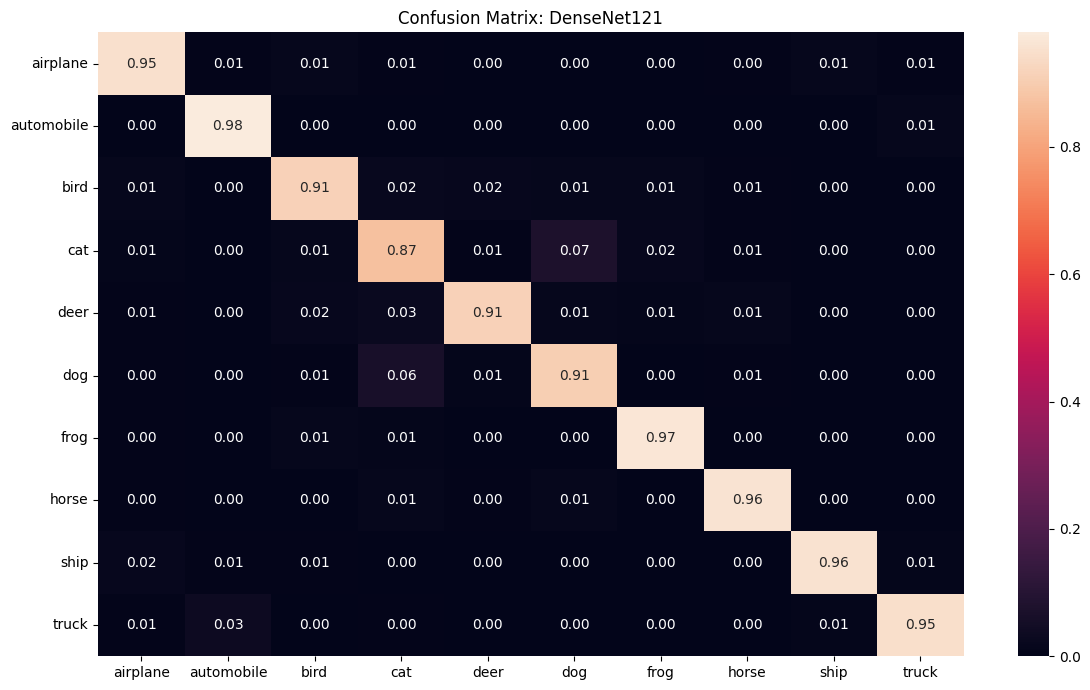

              precision    recall  f1-score   support

    airplane       0.94      0.95      0.94      1000
  automobile       0.95      0.98      0.97      1000
        bird       0.92      0.91      0.92      1000
         cat       0.86      0.87      0.86      1000
        deer       0.96      0.91      0.94      1000
         dog       0.89      0.91      0.90      1000
        frog       0.95      0.97      0.96      1000
       horse       0.96      0.96      0.96      1000
        ship       0.97      0.96      0.96      1000
       truck       0.96      0.95      0.95      1000

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000

Model zapisany do: /content/drive/MyDrive/TAI/sem2/DL/densenet_40/260119_DenseNet121_epoch50_dodany_dropout/model_DenseNet121_cifar10_260119.pth


In [ ]:
predicted_labels = []
actual_labels = []
model.eval()
class_names = train_dataset.classes

with torch.no_grad():
  for images, labels in tqdm(DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)):
    images, labels = images.to(device), labels.to(device)
    prediction_logits = model(images)
    predictions = prediction_logits.argmax(dim=1).cpu().numpy()
    predicted_labels.extend(predictions)
    actual_labels.extend(labels.cpu().numpy())

confusion_mat = confusion_matrix(actual_labels, predicted_labels)

# Normalizacja i wyświetlenie
confusion_df = pd.DataFrame(confusion_mat/np.sum(confusion_mat)*10, index=class_names, columns=class_names)

plt.figure(figsize=(12,7))
sn.heatmap(confusion_df, annot=True, fmt='.2f')
plt.title(f"Confusion Matrix: {model_name}")
plt.tight_layout()
if project_directory:
    plt.savefig(os.path.join(project_directory, f"confusion_matrix_model_{model_name}.png"))
plt.show()

report = classification_report(actual_labels, predicted_labels, target_names=class_names)
print(report)

if project_directory:
    with open(os.path.join(project_directory, f"classification_report_{model_name}.txt"), "w") as f:
        f.write(report)

save_path = os.path.join(project_directory, f"model_{model_name}_cifar10_{date}.pth")
torch.save(model.state_dict(), save_path)
print(f"Model zapisany do: {save_path}")